In [1]:
# Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataframe
df = pd.read_csv('upsampled_ss5.csv')
df.head()

,query_id,query_contents,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,...,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,Best Alpha,MRR,bin
0,725867,what is brewhaha,3,2,1,0.666667,0.333333,1,0,0,...,0.148836,0.156792,-0.221125,-0.171178,-0.005062,0.570391,-0.130698,-0.002731,0.500000,"(-0.001, 0.02]"
1,868525,what kind of gloves works for self tanners,8,3,5,0.375000,0.625000,1,0,0,...,-0.049571,0.416754,-0.239055,-0.037971,-0.031427,0.413592,0.228366,-0.005009,0.076923,"(-0.001, 0.02]"
2,581801,what can help arteries dilate,5,2,3,0.400000,0.600000,1,0,0,...,-0.089262,0.288245,-0.191944,-0.120245,0.413235,0.324774,-0.283617,0.003436,0.001205,"(-0.001, 0.02]"
3,559318,what are genetically modified foods impact on ...,8,3,5,0.375000,0.625000,1,0,0,...,0.171823,0.079556,0.174427,-0.453422,0.205726,0.329714,-0.119156,0.008188,1.000000,"(-0.001, 0.02]"
4,488021,requirements to become a drill sergeant,6,2,4,0.333333,0.666667,0,0,0,...,-0.143481,0.017615,0.132080,-0.428673,0.035787,0.184129,-0.238533,-0.004820,0.500000,"(-0.001, 0.02]"


In [7]:
bin_vals = df['bin'].unique()
print(bin_vals)

['(-0.001, 0.02]' '(0.02, 0.04]' '(0.04, 0.06]' '(0.06, 0.08]'
 '(0.08, 0.1]' '(0.1, 0.12]' '(0.12, 0.14]' '(0.14, 0.16]' '(0.16, 0.18]'
 '(0.18, 0.2]' '(0.2, 0.22]' '(0.22, 0.24]' '(0.24, 0.26]' '(0.26, 0.28]'
 '(0.28, 0.3]' '(0.3, 0.32]' '(0.32, 0.34]' '(0.34, 0.36]' '(0.36, 0.38]'
 '(0.38, 0.4]' '(0.4, 0.42]' '(0.42, 0.44]' '(0.44, 0.46]' '(0.46, 0.48]'
 '(0.48, 0.5]' '(0.5, 0.52]' '(0.52, 0.54]' '(0.54, 0.56]' '(0.56, 0.58]'
 '(0.58, 0.6]' '(0.6, 0.62]' '(0.62, 0.64]' '(0.64, 0.66]' '(0.66, 0.68]'
 '(0.68, 0.7]' '(0.7, 0.72]' '(0.72, 0.74]' '(0.74, 0.76]' '(0.76, 0.78]'
 '(0.78, 0.8]' '(0.8, 0.82]' '(0.82, 0.84]' '(0.84, 0.86]' '(0.86, 0.88]'
 '(0.88, 0.9]' '(0.9, 0.92]' '(0.92, 0.94]' '(0.94, 0.96]' '(0.96, 0.98]'
 '(0.98, 1.0]']


In [10]:
df.shape

(6980, 783)

In [11]:
buckets_train = []

for i in range(df.shape[0]):
    if df.iloc[i, 782] >= 0.8:
        buckets_train.append(4)
    elif df.iloc[i, 782] >= 0.6:
        buckets_train.append(3)
    elif df.iloc[i, 782] >= 0.4:
        buckets_train.append(2)
    elif df.iloc[i, 782] >= 0.2:
        buckets_train.append(1)
    else:
        buckets_train.append(0)

df["alpha_buckets"] = buckets_train

In [12]:
# X and y dataframes
X = df.drop(columns=['Best Alpha', 'alpha_buckets', 'query_contents'], axis=1)
y = np.asarray(df['alpha_buckets'], dtype="float64")

X.head()

,query_id,query_length,stopword_count,nonstopword_count,stopword_density,nonstopword_density,what,where,when,why,...,cls_759,cls_760,cls_761,cls_762,cls_763,cls_764,cls_765,cls_766,cls_767,MRR
0,1048585,6,2,4,0.333333,0.666667,1,0,0,0,...,-0.371679,0.132870,-0.316542,0.164232,-0.089220,-0.071347,-0.031938,0.285646,0.290846,0.500000
1,2,3,0,3,0.000000,1.000000,0,0,0,0,...,-0.239406,-0.098719,-0.050720,0.171317,-0.123599,-0.302324,0.148471,0.649183,-0.100653,0.500000
2,524332,5,0,5,0.000000,1.000000,0,0,0,0,...,-0.523775,0.629171,0.088614,0.271708,-0.158394,-0.384479,0.177981,0.435811,-0.153385,0.142857
3,1048642,4,2,2,0.500000,0.500000,1,0,0,0,...,-0.263777,0.258236,-0.068101,0.137655,-0.179666,-0.398831,-0.017433,0.020971,-0.071258,0.020833
4,524447,6,2,4,0.333333,0.666667,0,0,0,0,...,-0.287455,0.245836,-0.133143,0.376936,-0.210180,-0.285664,0.195498,0.727291,-0.124383,0.029412


In [13]:
print(y)

[2. 2. 0. ... 1. 1. 1.]


In [14]:
print(X.shape)

(6980, 781)


In [15]:
buckets = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
bucket_labels = [0, 1, 2, 3, 4]
y_bucketed = np.digitize(y, buckets[1:-1])
y_bucketed = y_bucketed - 1

In [16]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# Training and testing sets (CHANGE TEST SIZE?)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [18]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=300,
    random_state=42,
    verbose=True
)

In [19]:
print(y_train)

[0. 1. 0. ... 4. 4. 0.]


In [20]:
# Train/fit model
mlp.fit(X_train, y_train)

# Predictions
y_pred = mlp.predict(X_test)

Iteration 1, loss = 1.50560185
Iteration 2, loss = 1.27714312
Iteration 3, loss = 1.16404132
Iteration 4, loss = 1.03756767
Iteration 5, loss = 0.89697843
Iteration 6, loss = 0.75632611
Iteration 7, loss = 0.62592961
Iteration 8, loss = 0.52065209
Iteration 9, loss = 0.42875501
Iteration 10, loss = 0.35826916
Iteration 11, loss = 0.29346565
Iteration 12, loss = 0.24403667
Iteration 13, loss = 0.19184757
Iteration 14, loss = 0.15531706
Iteration 15, loss = 0.12572049
Iteration 16, loss = 0.10260854
Iteration 17, loss = 0.08223359
Iteration 18, loss = 0.06620712
Iteration 19, loss = 0.05230421
Iteration 20, loss = 0.04420796
Iteration 21, loss = 0.03534528
Iteration 22, loss = 0.02988066
Iteration 23, loss = 0.02555316
Iteration 24, loss = 0.02138597
Iteration 25, loss = 0.01930122
Iteration 26, loss = 0.01657097
Iteration 27, loss = 0.01380257
Iteration 28, loss = 0.01212370
Iteration 29, loss = 0.01082317
Iteration 30, loss = 0.00975070
Iteration 31, loss = 0.00888769
Iteration 32, los

Accuracy: 0.7414

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.67      0.70       384
         1.0       0.57      0.64      0.60       398
         2.0       0.68      0.66      0.67       235
         4.0       0.98      0.97      0.98       379

    accuracy                           0.74      1396
   macro avg       0.74      0.73      0.74      1396
weighted avg       0.75      0.74      0.74      1396


Confusion Matrix:
[[258 121   5   0]
 [ 88 256  54   0]
 [  3  72 154   6]
 [  0   0  12 367]]


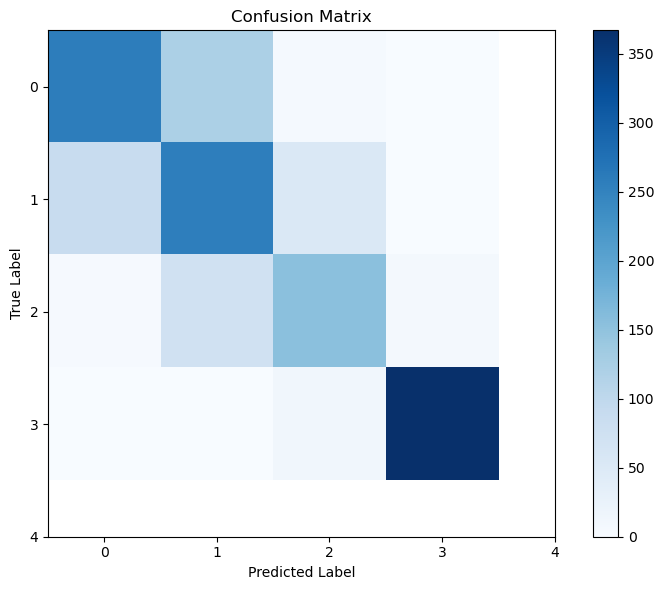

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(5)
plt.xticks(tick_marks, bucket_labels)
plt.yticks(tick_marks, bucket_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Checking errors
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")


MSE: 0.3145
RMSE: 0.5608
MAE: 0.2772
R²: 0.8682


In [23]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve
import seaborn as sns

y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Train MSE: {mse_train:.4f}, Test MSE: {mse_test:.4f}")
print(f"Train R2: {r2_train:.4f}, Test R2: {r2_test:.4f}")

Train MSE: 0.0000, Test MSE: 0.3145
Train R2: 1.0000, Test R2: 0.8682
